# 30 — Population structure learning: migrating the loop onto the edge-moving substrate

**Why this notebook exists (Plan P1).** The paper's §3 makes structure *learning* the
engine: the data must be able to revise a paradigm's edges, not just its node values.
nb29 proved the mechanism for a single agent — a **relational** observation (a row of `H`
reading a *combination* of nodes, e.g. the mass balance `calx − mass_change − gas`)
deposits genuine **off-diagonal** Fisher information `HᵀH`, so the coupling `Π[calx,mass]`
moves; a **node-wise** read (one node per row) deposits only *diagonal* Fisher, so the
off-diagonal structure is **frozen in the prior forever**.

The multi-agent loop (`src/structural/step.py`) used the node-wise operator, so every
population result so far ran on frozen edges. The migration is one flag:

```python
cfg = StructuralConfig(observation_operator="relational")   # was implicitly "node"
```

`step._transition` now calls `phlogiston.observation_operator(cfg)` to pick
`H_observable` (`"node"`, default — byte-identical to before) vs `gravimetric_H`
(`"relational"`). Everything downstream (the ρ-weights, the disagreement mask, the
γ machinery) was made operator-aware so the existing rollouts work unchanged in either
mode. **We change nothing but the substrate flag and watch the edges.**

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import dataclasses
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import StructuralConfig
from src.structural import step as S
from src.structural import shells, phlogiston as ph

KEY = jax.random.PRNGKey(0)
cfg_node = StructuralConfig(n_agents=40, n_steps=120, t_shift=40)        # default: 'node'
cfg_rel  = dataclasses.replace(cfg_node, observation_operator='relational')
print('node operator H  :', tuple(ph.observation_operator(cfg_node).shape), '(one row per measured node)')
print('relational op H  :', tuple(ph.observation_operator(cfg_rel).shape), '(+1 mass-balance row)')
print('relational rows  :', ph.observation_rows(cfg_rel)[-1], '<- reads a COMBINATION')

node operator H  : (9, 10) (one row per measured node)
relational op H  : (10, 10) (+1 mass-balance row)
relational rows  : mass_balance(calx-mass-gas) <- reads a COMBINATION


## §1 — The headline: belt edges learn only on the relational substrate

We run the *same* homogeneous population (everyone starts on the phlogiston prior) under
the two operators, take the full per-agent net trajectory with `run_trace_net`, and read
two couplings with `shells.edge_trace` (population-mean `Π[a,b]`, straight off the
precision — no inversion, robust to the improper hub prior):

* **belt** `Π[calx_heavier_than_metal, mass_change_sign]` — probed by the mass-balance
  relational row;
* **hub** `Π[combustion_releases, phlogiston]` — a strong prior edge that *no* experiment
  reads as a combination.

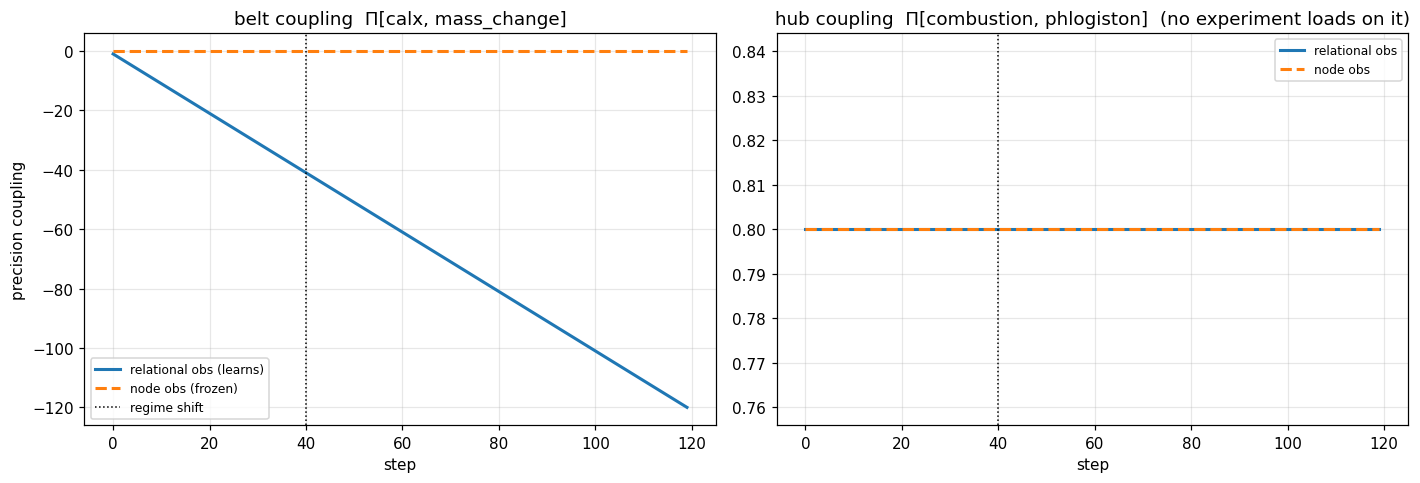

belt drift  | relational -119.00  vs  node +0.00
hub  drift  | relational +0.00  vs  node +0.00
=> relational moves the edge it probes (belt); both freeze the edge no experiment reads (hub).


In [2]:
Pi_node, _ = S.run_trace_net(cfg_node, S.init_state(cfg_node, KEY))
Pi_rel,  _ = S.run_trace_net(cfg_rel,  S.init_state(cfg_rel,  KEY))

belt = ('calx_heavier_than_metal', 'mass_change_sign')
hub  = ('combustion_releases', 'phlogiston')
e_node = shells.edge_trace(Pi_node, cfg_node, [belt, hub])
e_rel  = shells.edge_trace(Pi_rel,  cfg_rel,  [belt, hub])

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.5))
a0.plot(e_rel[belt],  lw=2, label='relational obs (learns)')
a0.plot(e_node[belt], lw=2, ls='--', label='node obs (frozen)')
a0.axvline(cfg_node.t_shift, color='k', ls=':', lw=1, label='regime shift')
a0.set_title('belt coupling  Π[calx, mass_change]'); a0.set_xlabel('step'); a0.set_ylabel('precision coupling'); a0.legend(fontsize=8)

a1.plot(e_rel[hub],  lw=2, label='relational obs')
a1.plot(e_node[hub], lw=2, ls='--', label='node obs')
a1.axvline(cfg_node.t_shift, color='k', ls=':', lw=1)
a1.set_title('hub coupling  Π[combustion, phlogiston]  (no experiment loads on it)')
a1.set_xlabel('step'); a1.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb30_edges.png'); plt.show()

print(f"belt drift  | relational {e_rel[belt][-1]-e_rel[belt][0]:+.2f}  vs  node {e_node[belt][-1]-e_node[belt][0]:+.2f}")
print(f"hub  drift  | relational {e_rel[hub][-1]-e_rel[hub][0]:+.2f}  vs  node {e_node[hub][-1]-e_node[hub][0]:+.2f}")
print('=> relational moves the edge it probes (belt); both freeze the edge no experiment reads (hub).')

## §2 — Where the off-diagonal Fisher landed

A snapshot of the population-mean precision `|Π|` (off-diagonal only) at the final step.
The relational operator has grown a dense `{calx, mass_change, gas}` block — the
mass-balance structure it learned — while the node operator's off-diagonal pattern is
exactly the prior's (hub star), untouched by the data.

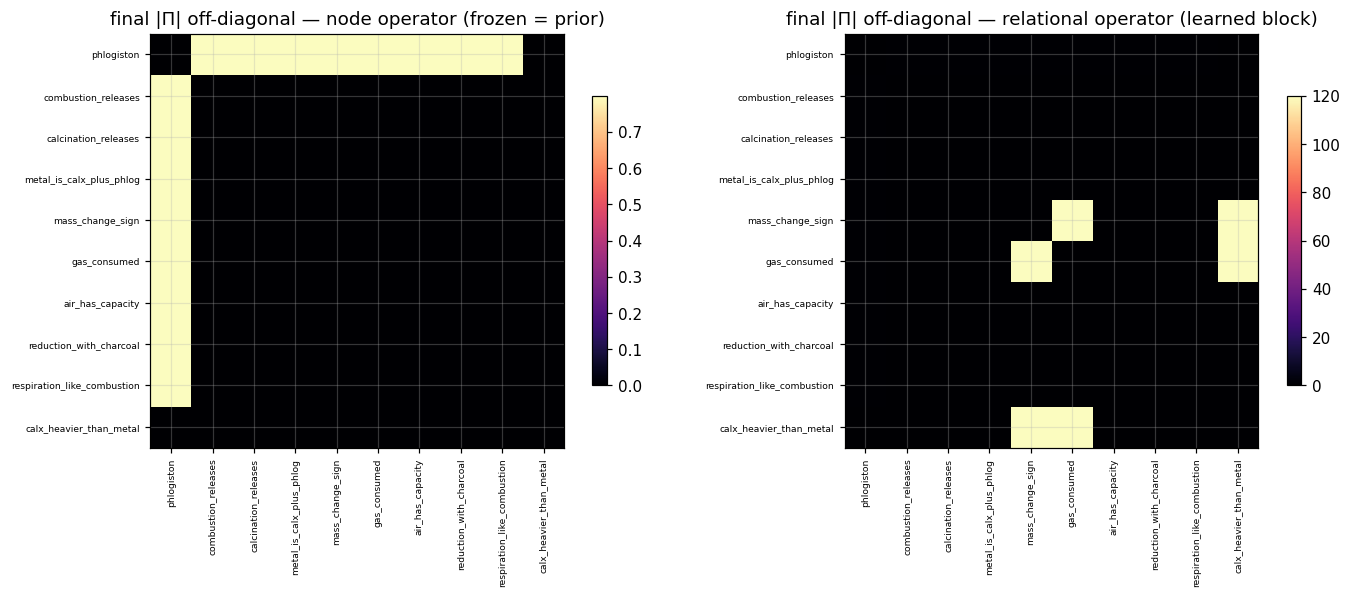

saved figures_nb30_precision.png


In [3]:
def offdiag(Pi_t):
    P = np.abs(np.asarray(Pi_t[-1]).mean(axis=0))   # population-mean final |Pi|
    np.fill_diagonal(P, 0.0)
    return P

names = cfg_node.node_names
fig, axs = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, P, ttl in [(axs[0], offdiag(Pi_node), "node operator (frozen = prior)"),
                   (axs[1], offdiag(Pi_rel),  "relational operator (learned block)")]:
    im = ax.imshow(P, cmap='magma'); ax.set_title(f'final |Π| off-diagonal — {ttl}')
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=6); ax.set_yticklabels(names, fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.savefig('figures_nb30_precision.png'); plt.show()
print('saved figures_nb30_precision.png')

## §3 — Level tracking is undisturbed: m(t) still crosses

The migration must add structure learning *without* breaking the level dynamics the
earlier notebooks relied on. The population order parameter `m(t)` (mean oxygen index)
still relaxes toward the post-shift truth under both operators — the regime shift is
read by the *direct* rows, which both operators carry. The relational operator simply
*also* moves the edges (§1).

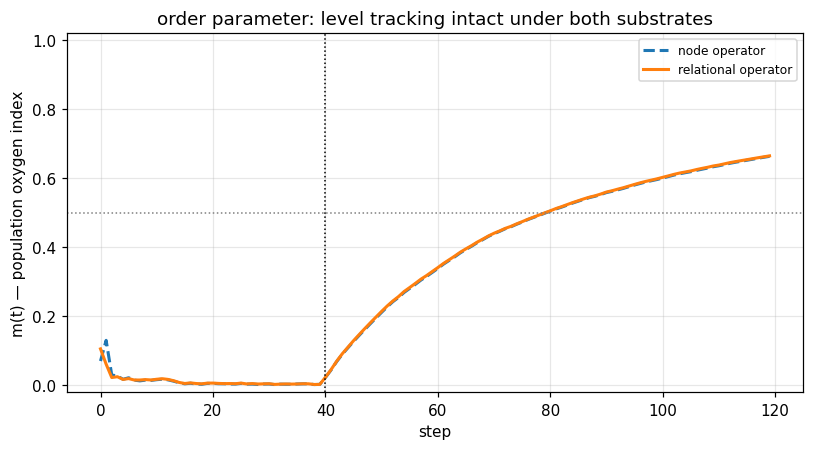

final m(t): node 0.663  relational 0.665


In [4]:
ms_node, _ = S.run_trace(cfg_node, S.init_state(cfg_node, KEY))
ms_rel,  _ = S.run_trace(cfg_rel,  S.init_state(cfg_rel,  KEY))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(np.asarray(ms_node), lw=2, ls='--', label='node operator')
ax.plot(np.asarray(ms_rel),  lw=2,           label='relational operator')
ax.axhline(0.5, color='grey', lw=1, ls=':'); ax.axvline(cfg_node.t_shift, color='k', ls=':', lw=1)
ax.set_xlabel('step'); ax.set_ylabel('m(t) — population oxygen index'); ax.set_ylim(-0.02, 1.02)
ax.set_title('order parameter: level tracking intact under both substrates'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb30_order.png'); plt.show()
print(f"final m(t): node {float(ms_node[-1]):.3f}  relational {float(ms_rel[-1]):.3f}")

## Verdict

The population loop now inherits structure learning by a single flag. On the **node**
substrate the off-diagonal couplings are pinned at the prior — the edges are decorative,
exactly the regime nb27–28 diagnosed. On the **relational** substrate the belt coupling
the mass-balance experiment probes actually moves, while edges no experiment reads stay
put and the order parameter is undisturbed. Every later phase runs here:

* **P2** — split the population by conservatism and ask whether the belt reorganises
  before the core (the staircase) now that the edges *can* move;
* **P3** — turn up γ (`core_governance`) so the conviction field silences the very
  mass-balance channel that moves structure, and look for evidential lock-in.